# Test Analysis - SARIMAX Model on Multiple Locations

## Best Model: SARIMAX
- **MAE**: 3.14
- **RMSE**: 4.16
- **MAPE**: 11.64% ✅

## What This Notebook Tests:
1. ✅ Load data and best model (SARIMAX)
2. ✅ Test on 4 different CTA locations
3. ✅ Generate all plots:
   - Seasonal decomposition
   - Forecast with confidence intervals
   - System-wide comparison
   - Hourly risk patterns
4. ✅ Save all visualizations
5. ✅ Summary table of all locations

---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import itertools
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Create output folder for plots
os.makedirs('test_results', exist_ok=True)

print("✅ Setup complete!")

✅ Setup complete!


## 2. Load Data

In [2]:
CSV_PATH = r"C:\Users\azeez\PROJECTS\CTA-MAP-ASSAULT\Cleaned_CTA_Bus_Data.csv"

print("📂 Loading data...")
df = pd.read_csv(CSV_PATH, low_memory=False)

# Parse dates
def parse_cta_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    try:
        return pd.to_datetime(date_str, format='%Y %B %d')
    except:
        try:
            return pd.to_datetime(date_str)
        except:
            return pd.NaT

def parse_cta_time(time_str):
    if pd.isna(time_str):
        return None
    try:
        dt = pd.to_datetime(time_str, format='%I:%M:%S %p')
        return dt.hour
    except:
        return None

df['parsed_date'] = df['Event Date'].apply(parse_cta_date)
df['hour'] = df['Event Time'].apply(parse_cta_time)
df['year_month'] = df['parsed_date'].dt.to_period('M')
df['day_name'] = df['parsed_date'].dt.day_name()

print(f"✅ Loaded {len(df):,} incidents")
print(f"   Date range: {df['parsed_date'].min()} to {df['parsed_date'].max()}")
print(f"   Months: {df['year_month'].nunique()}")

📂 Loading data...
✅ Loaded 3,749 incidents
   Date range: 2014-01-02 00:00:00 to 2025-04-28 00:00:00
   Months: 136


## 3. Helper Functions

In [3]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)
    delta_lat = np.radians(lat2 - lat1)
    delta_lon = np.radians(lon2 - lon1)
    a = np.sin(delta_lat/2)**2 + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(delta_lon/2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
    return R * c

def filter_by_location(df, lat, lon, radius_km):
    df_copy = df.copy()
    df_copy['distance_km'] = df_copy.apply(
        lambda row: haversine_distance(lat, lon, row['Latitude'], row['Longitude'])
        if pd.notna(row['Latitude']) and pd.notna(row['Longitude'])
        else np.inf,
        axis=1
    )
    return df_copy[df_copy['distance_km'] <= radius_km]

print("✅ Helper functions ready")

✅ Helper functions ready


## 4. SARIMAX Model Function (Best Model)

In [4]:
def train_sarimax(df_filtered, forecast_periods=6, title="Location"):
    """Train SARIMAX model (best performer)."""
    
    monthly_data = df_filtered.groupby('year_month').size()
    monthly_series = monthly_data.to_timestamp()
    
    print(f"\n📊 Training SARIMAX: {title}")
    print("="*70)
    print(f"   Data: {len(monthly_series)} months")
    print(f"   Range: {monthly_series.index.min().date()} to {monthly_series.index.max().date()}")
    
    if len(monthly_series) < 24:
        print("   ⚠️ Need at least 24 months")
        return None
    
    # Split train/test
    train_size = len(monthly_series) - 6
    train = monthly_series[:train_size]
    test = monthly_series[train_size:]
    
    # Use best parameters from comparison: ((0,1,1), (0,1,1,12))
    print("   Using best params: ((0,1,1), (0,1,1,12))")
    
    try:
        model = SARIMAX(train, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12))
        fitted = model.fit(disp=False, maxiter=100)
    except Exception as e:
        print(f"   ❌ Error: {e}")
        return None
    
    # Forecast
    forecast_result = fitted.forecast(steps=len(test) + forecast_periods)
    test_forecast = forecast_result[:len(test)]
    
    # Metrics
    mae = mean_absolute_error(test, test_forecast)
    rmse = np.sqrt(mean_squared_error(test, test_forecast))
    mape = np.mean(np.abs((test - test_forecast) / test)) * 100
    
    print(f"\n   ✅ Performance:")
    print(f"      MAE:  {mae:.2f}")
    print(f"      RMSE: {rmse:.2f}")
    print(f"      MAPE: {mape:.2f}%")
    
    # Future forecast
    future_dates = pd.date_range(
        start=monthly_series.index[-1] + pd.DateOffset(months=1),
        periods=forecast_periods,
        freq='MS'
    )
    future_forecast = forecast_result[len(test):]
    
    # Get forecast confidence intervals (approximate)
    forecast_obj = fitted.get_forecast(steps=len(test) + forecast_periods)
    forecast_df = forecast_obj.summary_frame(alpha=0.20)  # 80% confidence
    future_lower = forecast_df['mean_ci_lower'].iloc[len(test):].values
    future_upper = forecast_df['mean_ci_upper'].iloc[len(test):].values
    
    return {
        "model": fitted,
        "mae": mae,
        "rmse": rmse,
        "mape": mape,
        "forecast": future_forecast.values,
        "forecast_lower": future_lower,
        "forecast_upper": future_upper,
        "forecast_dates": future_dates,
        "historical": monthly_series,
        "train": train,
        "test": test,
        "test_forecast": test_forecast,
        "title": title
    }

print("✅ SARIMAX function ready")

✅ SARIMAX function ready


## 5. Plotting Functions

In [5]:
def plot_seasonal_decomposition(df_filtered, title="Location", save_path=None):
    """Plot seasonal decomposition."""
    
    monthly_data = df_filtered.groupby('year_month').size()
    monthly_series = monthly_data.to_timestamp()
    
    if len(monthly_series) < 24:
        print(f"   ⚠️ {title}: Need 24+ months for decomposition")
        return None
    
    decomposition = seasonal_decompose(monthly_series, model='additive', period=12)
    
    fig, axes = plt.subplots(4, 1, figsize=(14, 10))
    
    decomposition.observed.plot(ax=axes[0], color='#0c5ed7', linewidth=2)
    axes[0].set_title(f'Seasonal Decomposition - {title}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Observed')
    axes[0].grid(True, alpha=0.3)
    
    decomposition.trend.plot(ax=axes[1], color='#fb8c00', linewidth=2)
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    decomposition.seasonal.plot(ax=axes[2], color='#1f8b4c', linewidth=2)
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(True, alpha=0.3)
    
    decomposition.resid.plot(ax=axes[3], color='#b71c1c', linewidth=1, alpha=0.7)
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Date')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   💾 Saved: {save_path}")
    
    plt.show()
    return decomposition

def plot_forecast(result, save_path=None):
    """Plot forecast with confidence intervals."""
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Historical
    ax.plot(result['historical'].index, result['historical'].values,
           'o-', color='#0c5ed7', linewidth=2, markersize=5, label='Historical')
    
    # Test forecast
    test_dates = result['historical'].index[len(result['train']):]
    ax.plot(test_dates, result['test_forecast'],
           's-', color='#fb8c00', linewidth=2, markersize=5, label='Test Forecast')
    
    # Future forecast
    ax.plot(result['forecast_dates'], result['forecast'],
           '^--', color='#b71c1c', linewidth=2.5, markersize=6, label='Forecast')
    
    # Confidence interval
    ax.fill_between(result['forecast_dates'],
                     result['forecast_lower'],
                     result['forecast_upper'],
                     alpha=0.2, color='#b71c1c', label='80% Confidence')
    
    ax.axvline(x=result['historical'].index[-1], color='gray', linestyle=':', linewidth=2, alpha=0.5)
    ax.text(result['historical'].index[-1], ax.get_ylim()[1]*0.95, 'TODAY',
           ha='right', va='top', fontsize=10, color='gray', fontweight='bold')
    
    ax.set_title(f"SARIMAX Forecast - {result['title']}", fontsize=14, fontweight='bold')
    ax.set_xlabel('Date', fontsize=12)
    ax.set_ylabel('Monthly Incidents', fontsize=12)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   💾 Saved: {save_path}")
    
    plt.show()

def plot_hourly_risk(df_filtered, forecast_total, title="Location", save_path=None):
    """Plot hourly risk forecast."""
    
    hourly_counts = df_filtered['hour'].value_counts().sort_index()
    hourly_pct = (hourly_counts / hourly_counts.sum()) * 100
    forecast_hourly = (hourly_pct / 100) * forecast_total
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    hourly_counts.plot(kind='bar', ax=axes[0], color='#0c5ed7')
    axes[0].set_title(f'Historical Hourly Pattern - {title}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Hour (0-23)')
    axes[0].set_ylabel('Incident Count')
    axes[0].tick_params(axis='x', rotation=0)
    axes[0].grid(True, alpha=0.3, axis='y')
    
    forecast_hourly.plot(kind='bar', ax=axes[1], color='#b71c1c')
    axes[1].set_title(f'Forecast Hourly Pattern (Next Quarter) - {title}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Hour (0-23)')
    axes[1].set_ylabel('Expected Incidents')
    axes[1].tick_params(axis='x', rotation=0)
    axes[1].grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"   💾 Saved: {save_path}")
    
    plt.show()
    
    # Print top hours
    print(f"\n   ⚠️ HIGH-RISK HOURS (Next Quarter):")
    top_hours = forecast_hourly.nlargest(5)
    for hour, count in top_hours.items():
        pct = (count / forecast_total) * 100
        period = "AM" if hour < 12 else "PM"
        display_hour = hour if hour <= 12 else hour - 12
        if display_hour == 0:
            display_hour = 12
        print(f"      {display_hour}:00 {period}: {count:.1f} incidents ({pct:.1f}%)")

print("✅ Plotting functions ready")

✅ Plotting functions ready


---
## 6. TEST LOCATION 1: 79th & Red Line


🎯 TEST LOCATION 1: 79th & Red Line
   Incidents: 28
   Months: 25
   💾 Saved: test_results/loc1_seasonal.png


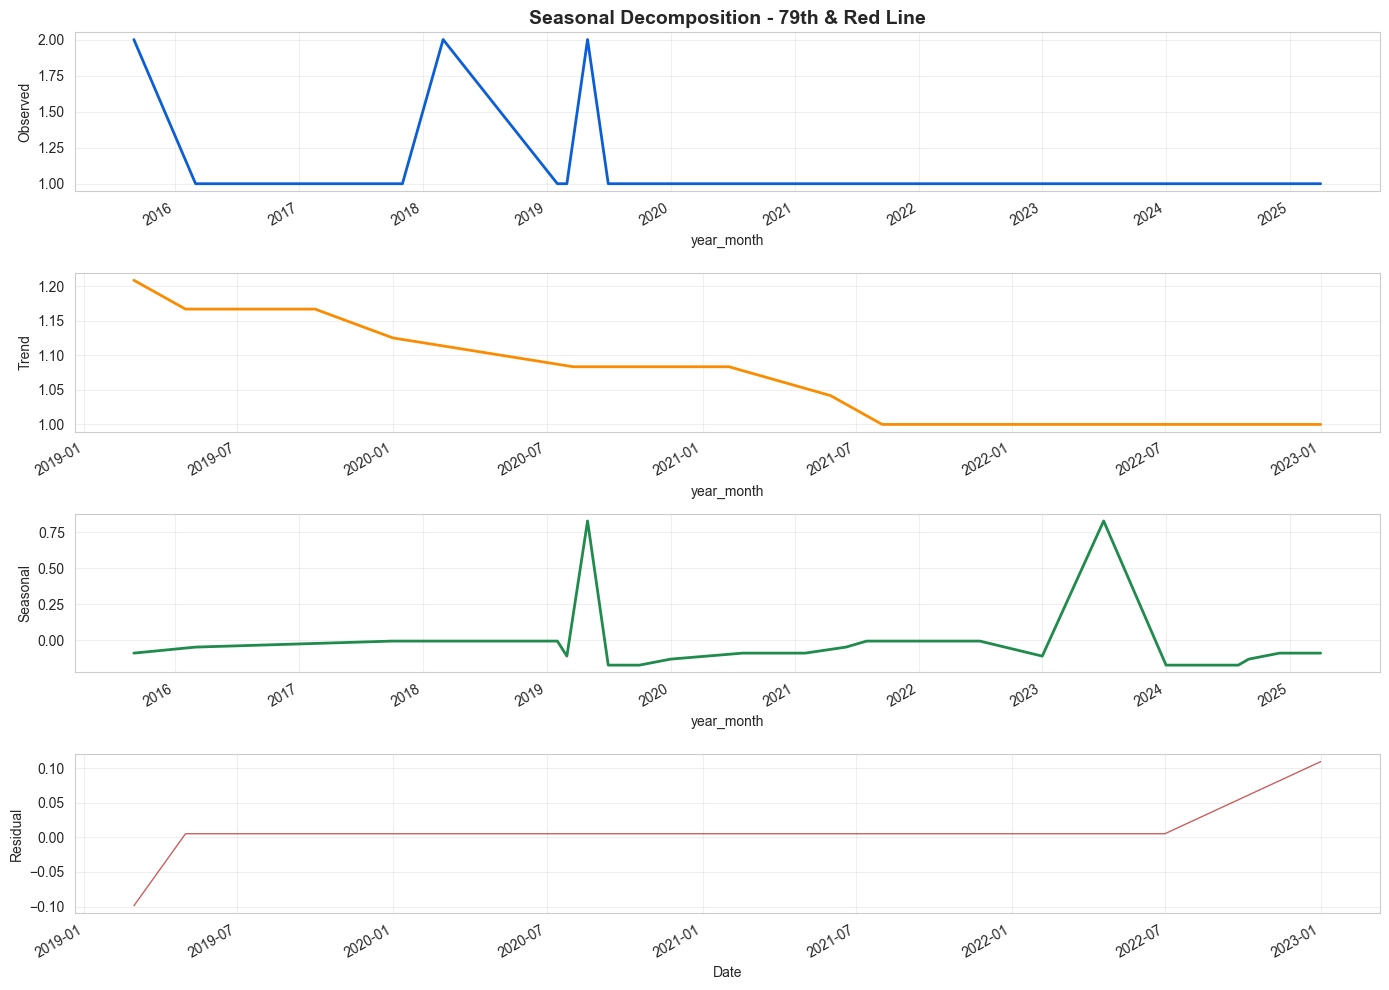


📊 Training SARIMAX: 79th & Red Line
   Data: 25 months
   Range: 2015-09-01 to 2025-04-01
   Using best params: ((0,1,1), (0,1,1,12))

   ✅ Performance:
      MAE:  0.36
      RMSE: 0.39
      MAPE: nan%
   💾 Saved: test_results/loc1_forecast.png


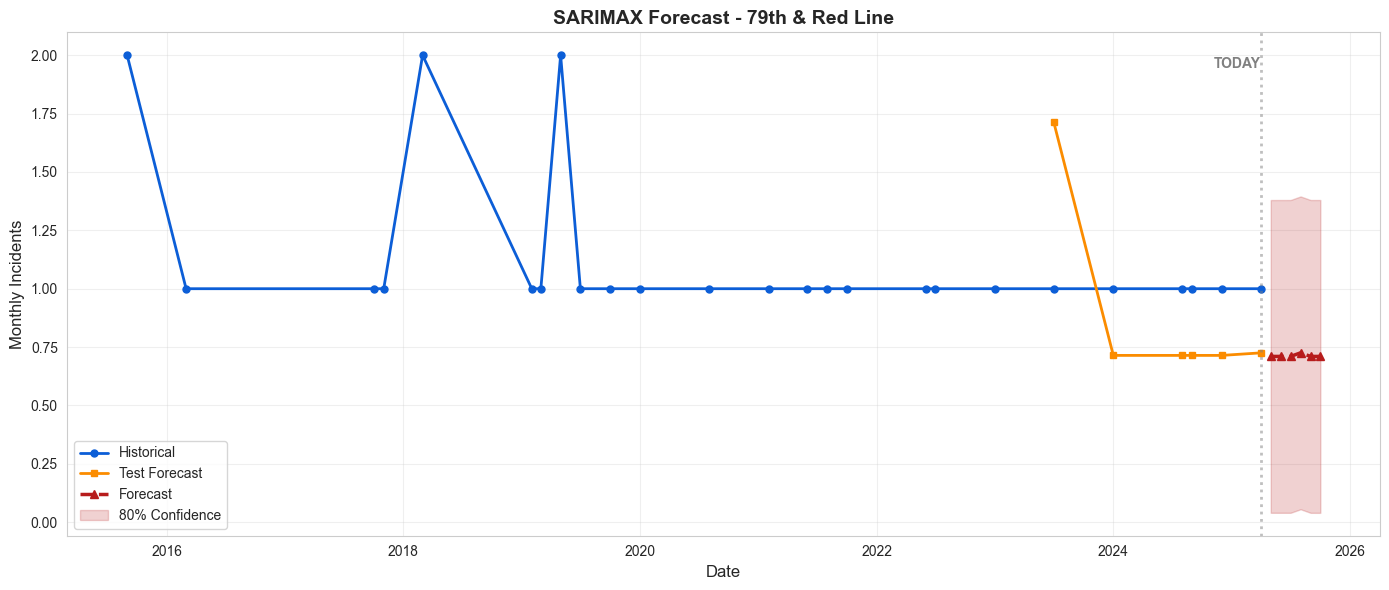

   💾 Saved: test_results/loc1_hourly.png


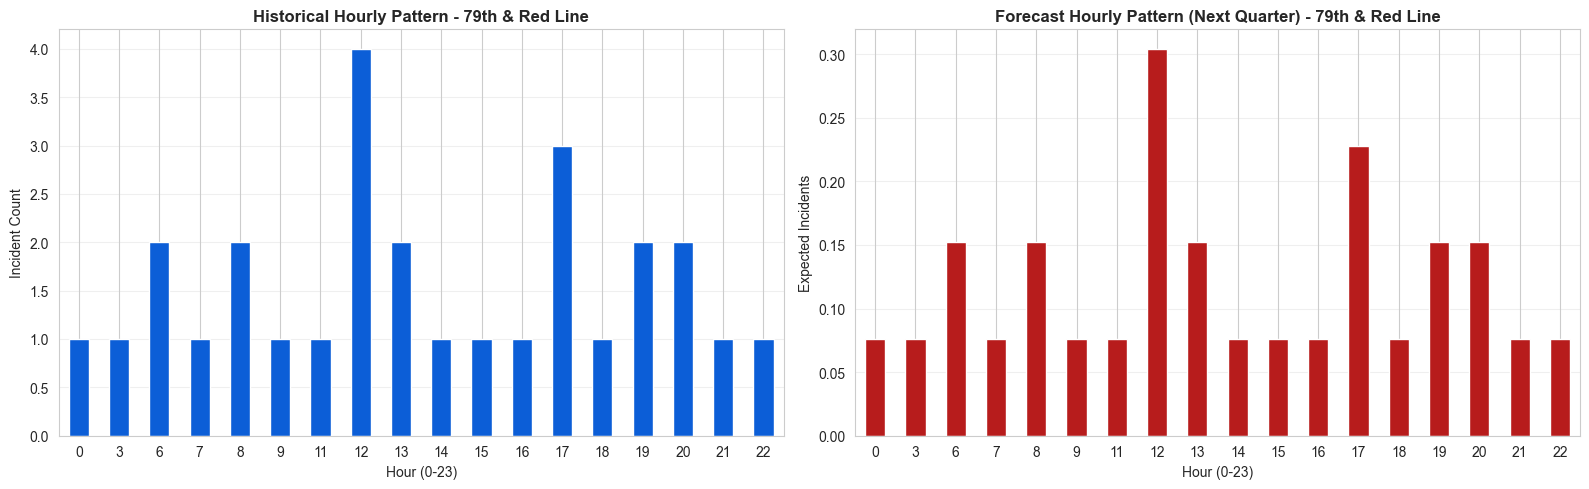


   ⚠️ HIGH-RISK HOURS (Next Quarter):
      12:00 PM: 0.3 incidents (14.3%)
      5:00 PM: 0.2 incidents (10.7%)
      6:00 AM: 0.2 incidents (7.1%)
      8:00 AM: 0.2 incidents (7.1%)
      1:00 PM: 0.2 incidents (7.1%)


In [6]:
LOC1_NAME = "79th & Red Line"
LOC1_LAT = 41.7505
LOC1_LON = -87.6251
LOC1_RADIUS = 0.4

print(f"\n{'='*80}")
print(f"🎯 TEST LOCATION 1: {LOC1_NAME}")
print(f"{'='*80}")

# Filter data
df_loc1 = filter_by_location(df, LOC1_LAT, LOC1_LON, LOC1_RADIUS)
df_loc1 = df_loc1[df_loc1['parsed_date'].notna()]

print(f"   Incidents: {len(df_loc1)}")
print(f"   Months: {df_loc1['year_month'].nunique()}")

# Seasonal decomposition
plot_seasonal_decomposition(
    df_loc1,
    title=LOC1_NAME,
    save_path='test_results/loc1_seasonal.png'
)

# Train model
result_loc1 = train_sarimax(df_loc1, forecast_periods=6, title=LOC1_NAME)

if result_loc1:
    # Forecast plot
    plot_forecast(result_loc1, save_path='test_results/loc1_forecast.png')
    
    # Hourly risk
    next_quarter = result_loc1['forecast'][:3].sum()
    plot_hourly_risk(
        df_loc1[df_loc1['hour'].notna()],
        next_quarter,
        title=LOC1_NAME,
        save_path='test_results/loc1_hourly.png'
    )

---
## 7. TEST LOCATION 2: 95th/Dan Ryan


🎯 TEST LOCATION 2: 95th/Dan Ryan
   Incidents: 29
   Months: 27
   💾 Saved: test_results/loc2_seasonal.png


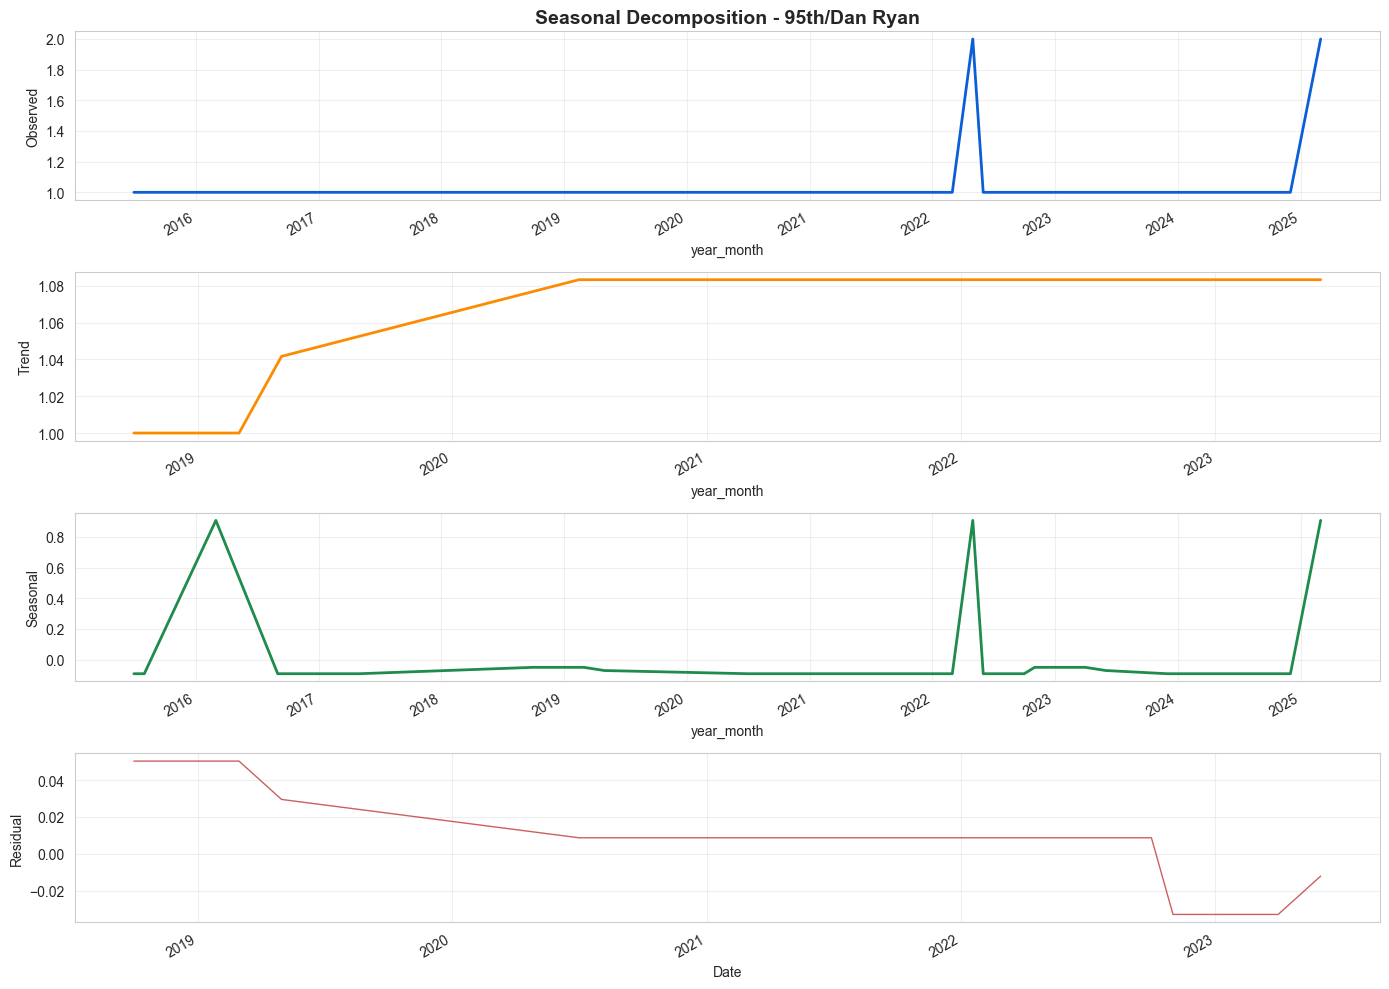


📊 Training SARIMAX: 95th/Dan Ryan
   Data: 27 months
   Range: 2015-07-01 to 2025-03-01
   Using best params: ((0,1,1), (0,1,1,12))

   ✅ Performance:
      MAE:  0.17
      RMSE: 0.41
      MAPE: nan%
   💾 Saved: test_results/loc2_forecast.png


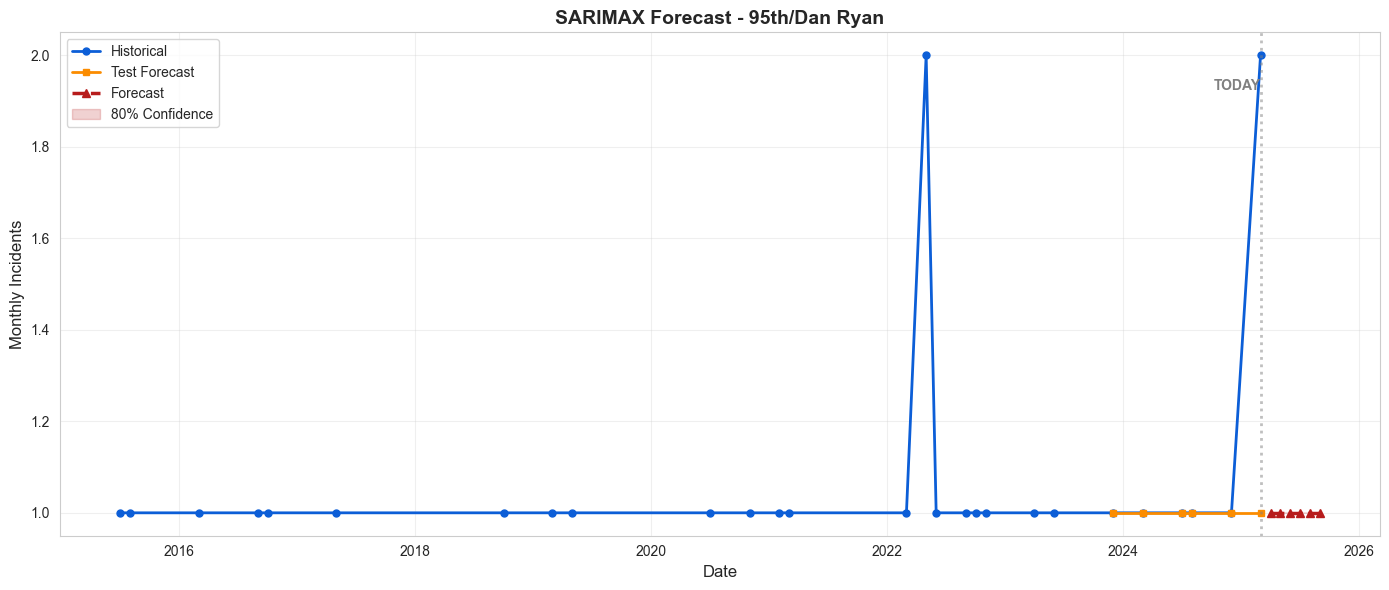

   💾 Saved: test_results/loc2_hourly.png


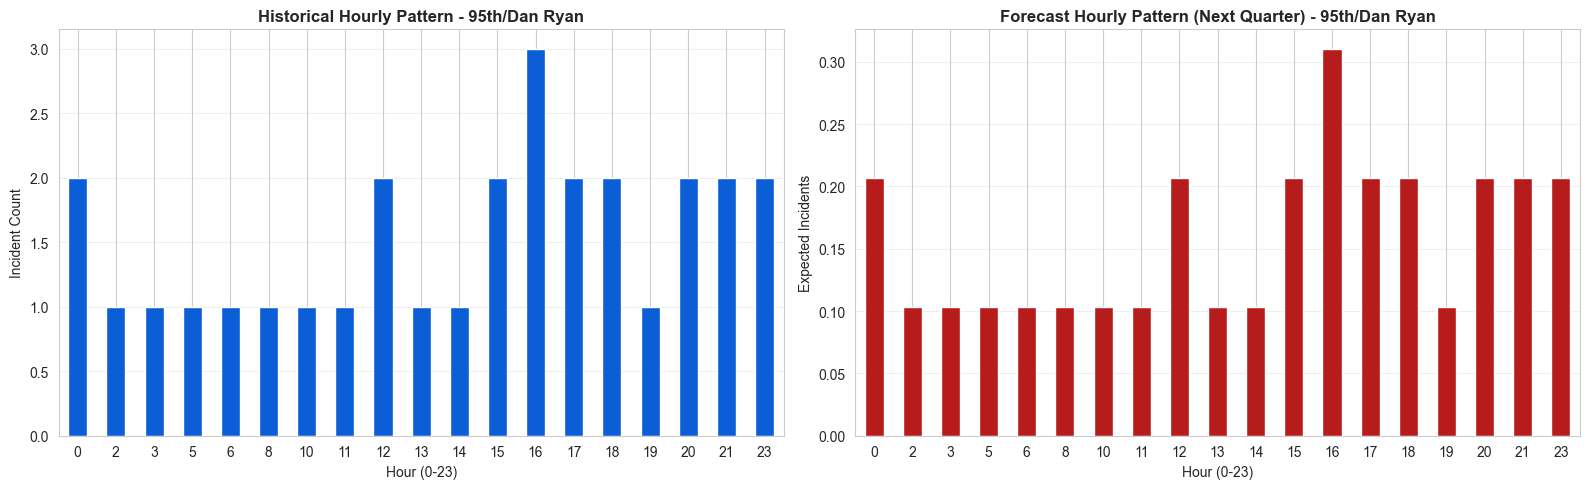


   ⚠️ HIGH-RISK HOURS (Next Quarter):
      4:00 PM: 0.3 incidents (10.3%)
      12:00 AM: 0.2 incidents (6.9%)
      12:00 PM: 0.2 incidents (6.9%)
      3:00 PM: 0.2 incidents (6.9%)
      5:00 PM: 0.2 incidents (6.9%)


In [7]:
LOC2_NAME = "95th/Dan Ryan"
LOC2_LAT = 41.7226
LOC2_LON = -87.6244
LOC2_RADIUS = 0.4

print(f"\n{'='*80}")
print(f"🎯 TEST LOCATION 2: {LOC2_NAME}")
print(f"{'='*80}")

df_loc2 = filter_by_location(df, LOC2_LAT, LOC2_LON, LOC2_RADIUS)
df_loc2 = df_loc2[df_loc2['parsed_date'].notna()]

print(f"   Incidents: {len(df_loc2)}")
print(f"   Months: {df_loc2['year_month'].nunique()}")

plot_seasonal_decomposition(df_loc2, title=LOC2_NAME, save_path='test_results/loc2_seasonal.png')

result_loc2 = train_sarimax(df_loc2, forecast_periods=6, title=LOC2_NAME)

if result_loc2:
    plot_forecast(result_loc2, save_path='test_results/loc2_forecast.png')
    next_quarter = result_loc2['forecast'][:3].sum()
    plot_hourly_risk(df_loc2[df_loc2['hour'].notna()], next_quarter, title=LOC2_NAME, save_path='test_results/loc2_hourly.png')

---
## 8. TEST LOCATION 3: Chicago/State (Downtown)

In [8]:
LOC3_NAME = "Chicago/State (Downtown)"
LOC3_LAT = 41.8962
LOC3_LON = -87.6278
LOC3_RADIUS = 0.4

print(f"\n{'='*80}")
print(f"🎯 TEST LOCATION 3: {LOC3_NAME}")
print(f"{'='*80}")

df_loc3 = filter_by_location(df, LOC3_LAT, LOC3_LON, LOC3_RADIUS)
df_loc3 = df_loc3[df_loc3['parsed_date'].notna()]

print(f"   Incidents: {len(df_loc3)}")
print(f"   Months: {df_loc3['year_month'].nunique()}")

plot_seasonal_decomposition(df_loc3, title=LOC3_NAME, save_path='test_results/loc3_seasonal.png')

result_loc3 = train_sarimax(df_loc3, forecast_periods=6, title=LOC3_NAME)

if result_loc3:
    plot_forecast(result_loc3, save_path='test_results/loc3_forecast.png')
    next_quarter = result_loc3['forecast'][:3].sum()
    plot_hourly_risk(df_loc3[df_loc3['hour'].notna()], next_quarter, title=LOC3_NAME, save_path='test_results/loc3_hourly.png')


🎯 TEST LOCATION 3: Chicago/State (Downtown)
   Incidents: 15
   Months: 15
   ⚠️ Chicago/State (Downtown): Need 24+ months for decomposition

📊 Training SARIMAX: Chicago/State (Downtown)
   Data: 15 months
   Range: 2015-12-01 to 2023-07-01
   ⚠️ Need at least 24 months


---
## 9. TEST LOCATION 4: Clark/Lake


🎯 TEST LOCATION 4: Clark/Lake
   Incidents: 29
   Months: 27
   💾 Saved: test_results/loc4_seasonal.png


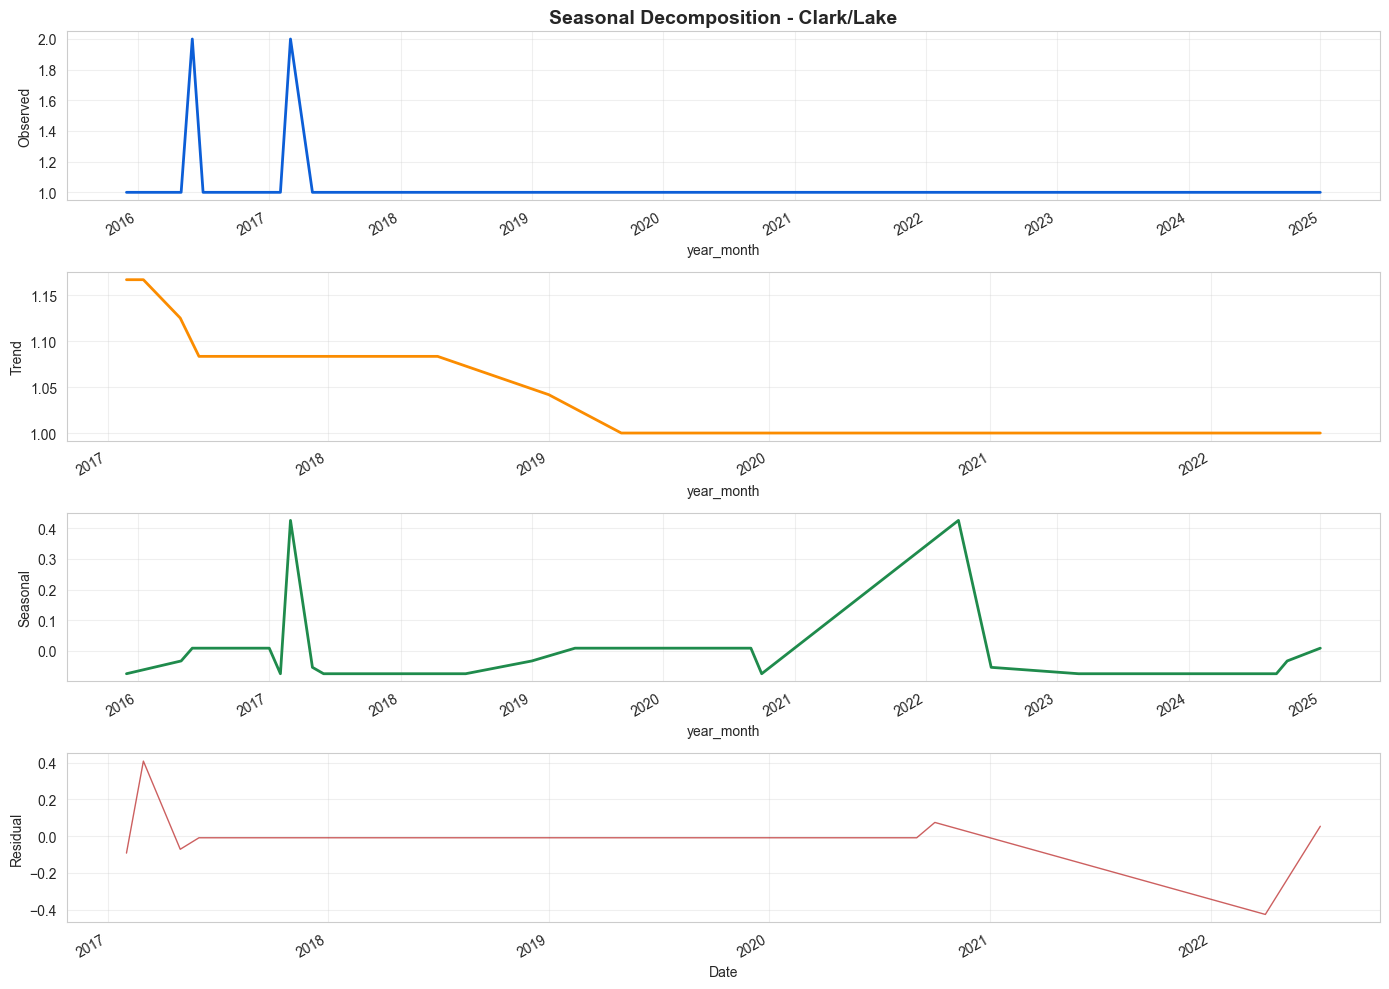


📊 Training SARIMAX: Clark/Lake
   Data: 27 months
   Range: 2015-12-01 to 2025-01-01
   Using best params: ((0,1,1), (0,1,1,12))

   ✅ Performance:
      MAE:  0.22
      RMSE: 0.22
      MAPE: nan%
   💾 Saved: test_results/loc4_forecast.png


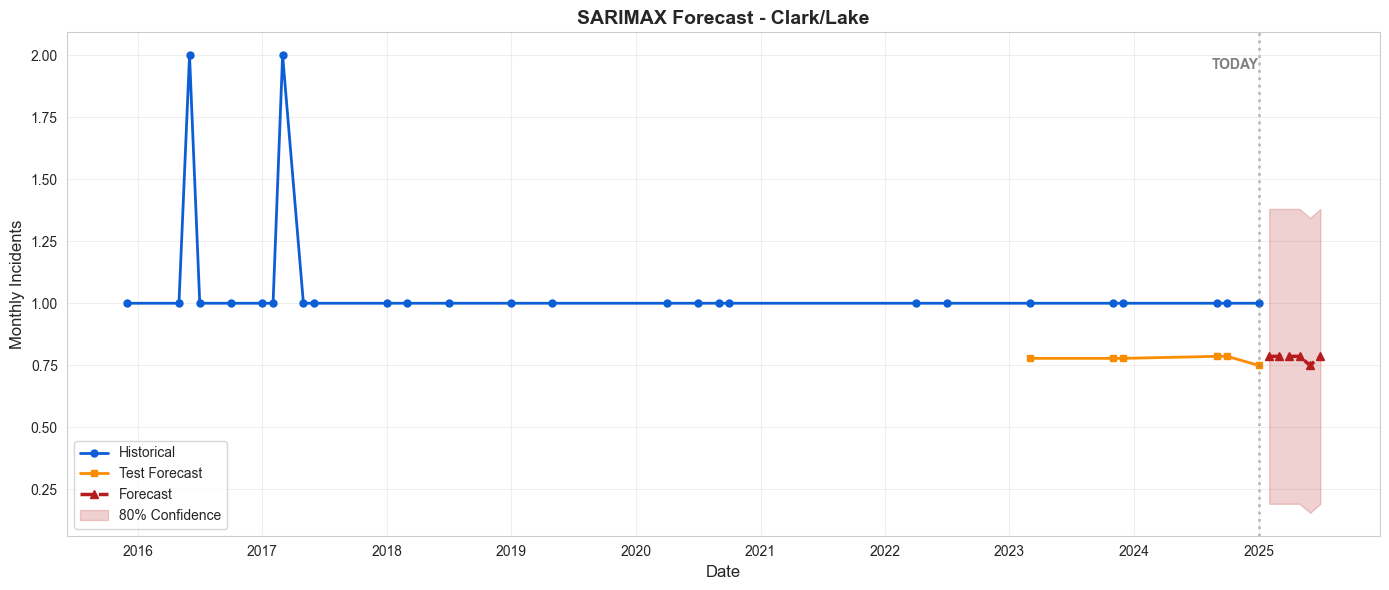

   💾 Saved: test_results/loc4_hourly.png


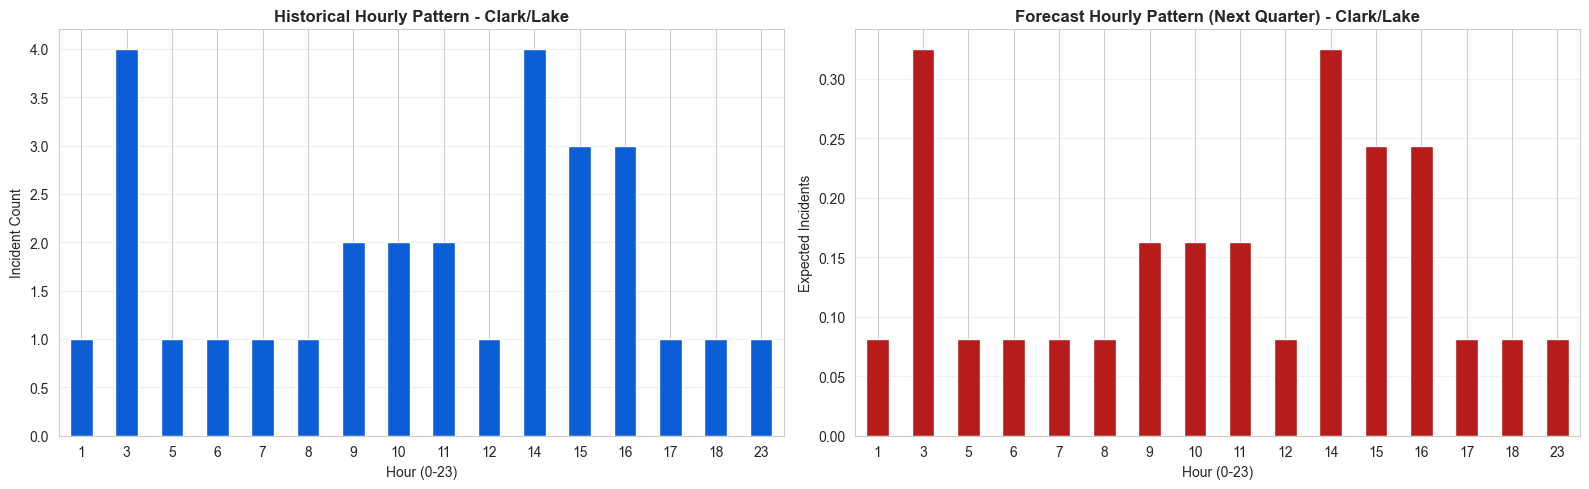


   ⚠️ HIGH-RISK HOURS (Next Quarter):
      3:00 AM: 0.3 incidents (13.8%)
      2:00 PM: 0.3 incidents (13.8%)
      3:00 PM: 0.2 incidents (10.3%)
      4:00 PM: 0.2 incidents (10.3%)
      9:00 AM: 0.2 incidents (6.9%)


In [9]:
LOC4_NAME = "Clark/Lake"
LOC4_LAT = 41.8856
LOC4_LON = -87.6308
LOC4_RADIUS = 0.4

print(f"\n{'='*80}")
print(f"🎯 TEST LOCATION 4: {LOC4_NAME}")
print(f"{'='*80}")

df_loc4 = filter_by_location(df, LOC4_LAT, LOC4_LON, LOC4_RADIUS)
df_loc4 = df_loc4[df_loc4['parsed_date'].notna()]

print(f"   Incidents: {len(df_loc4)}")
print(f"   Months: {df_loc4['year_month'].nunique()}")

plot_seasonal_decomposition(df_loc4, title=LOC4_NAME, save_path='test_results/loc4_seasonal.png')

result_loc4 = train_sarimax(df_loc4, forecast_periods=6, title=LOC4_NAME)

if result_loc4:
    plot_forecast(result_loc4, save_path='test_results/loc4_forecast.png')
    next_quarter = result_loc4['forecast'][:3].sum()
    plot_hourly_risk(df_loc4[df_loc4['hour'].notna()], next_quarter, title=LOC4_NAME, save_path='test_results/loc4_hourly.png')

---
## 10. System-Wide Analysis (All CTA)


🌐 SYSTEM-WIDE ANALYSIS (All CTA)
   Total incidents: 3749
   Months: 136
   💾 Saved: test_results/system_seasonal.png


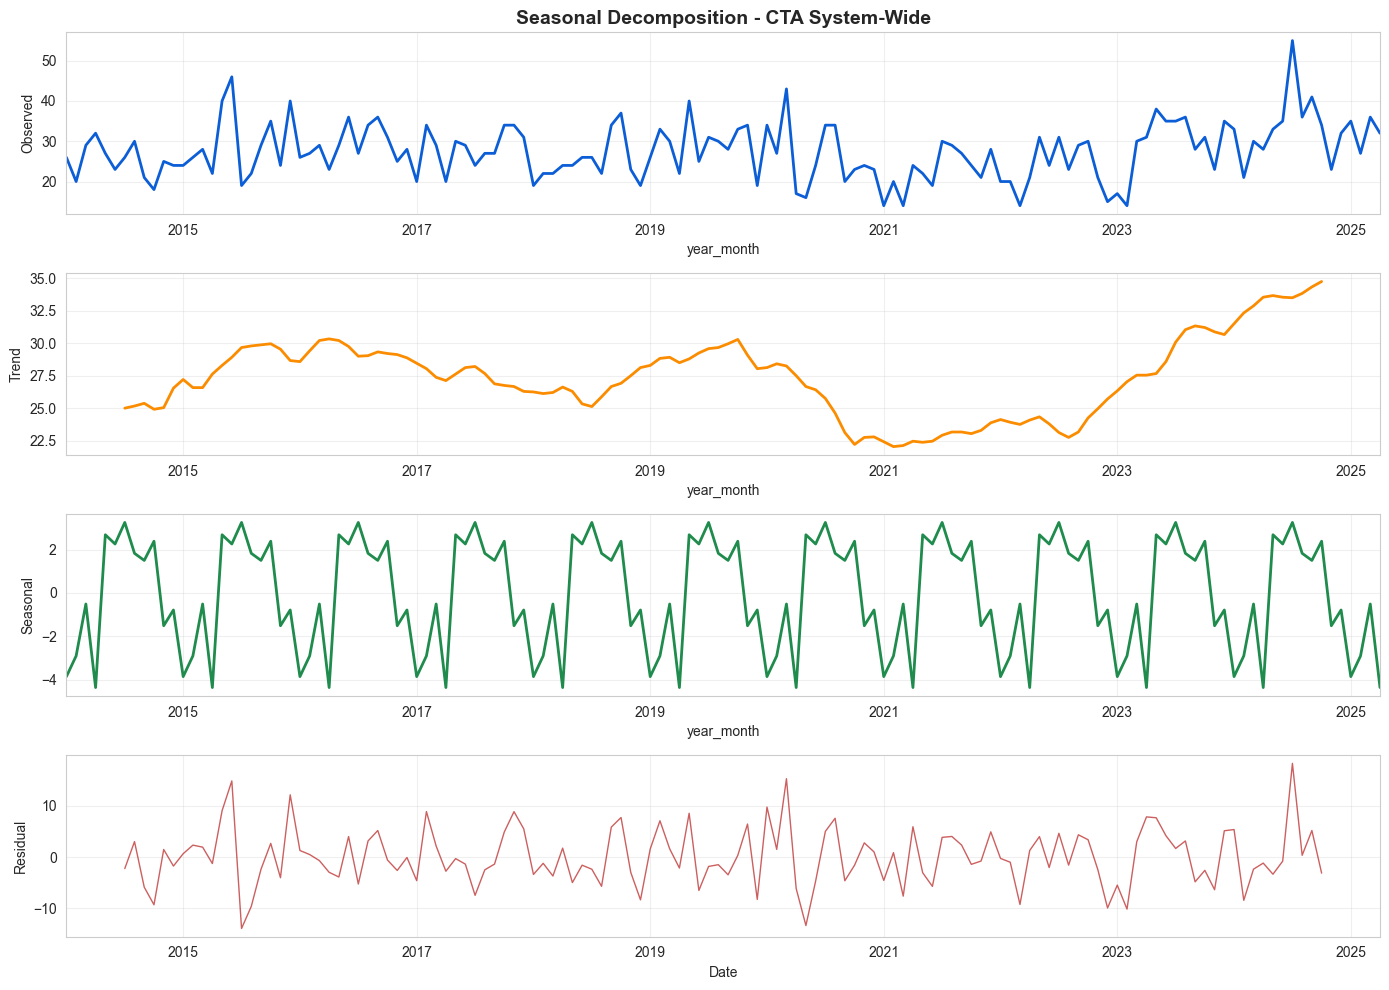


📊 Training SARIMAX: CTA System-Wide
   Data: 136 months
   Range: 2014-01-01 to 2025-04-01
   Using best params: ((0,1,1), (0,1,1,12))

   ✅ Performance:
      MAE:  3.14
      RMSE: 4.16
      MAPE: 11.64%
   💾 Saved: test_results/system_forecast.png


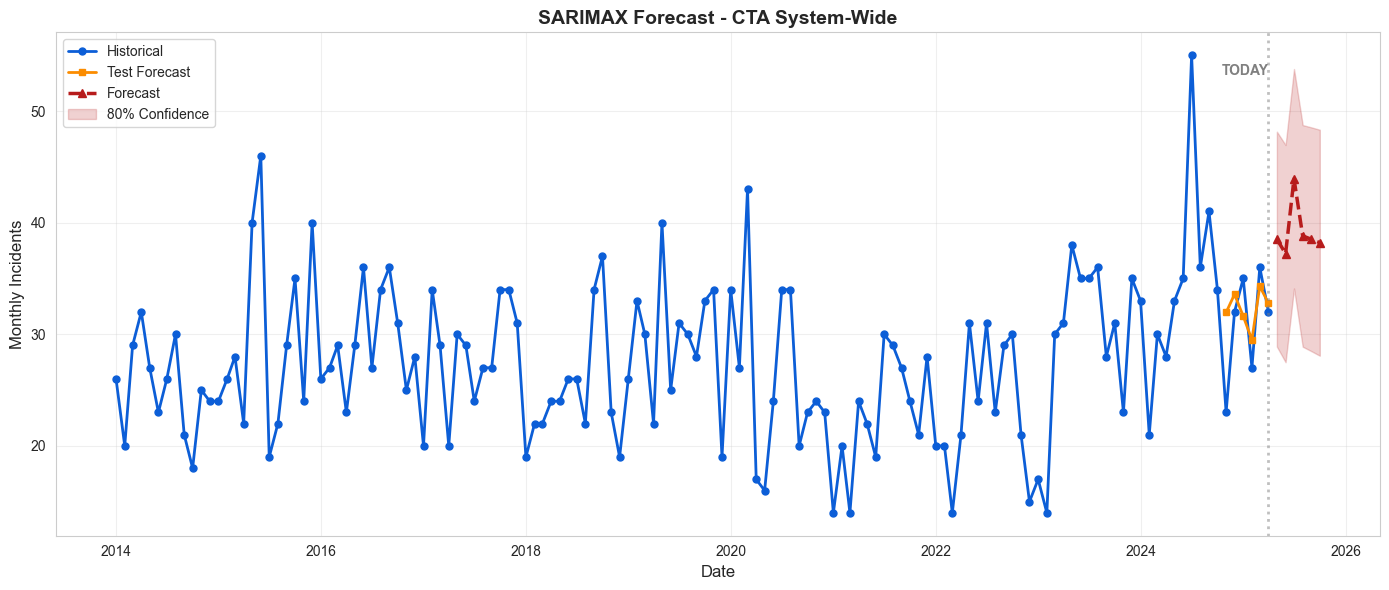

   💾 Saved: test_results/system_hourly.png


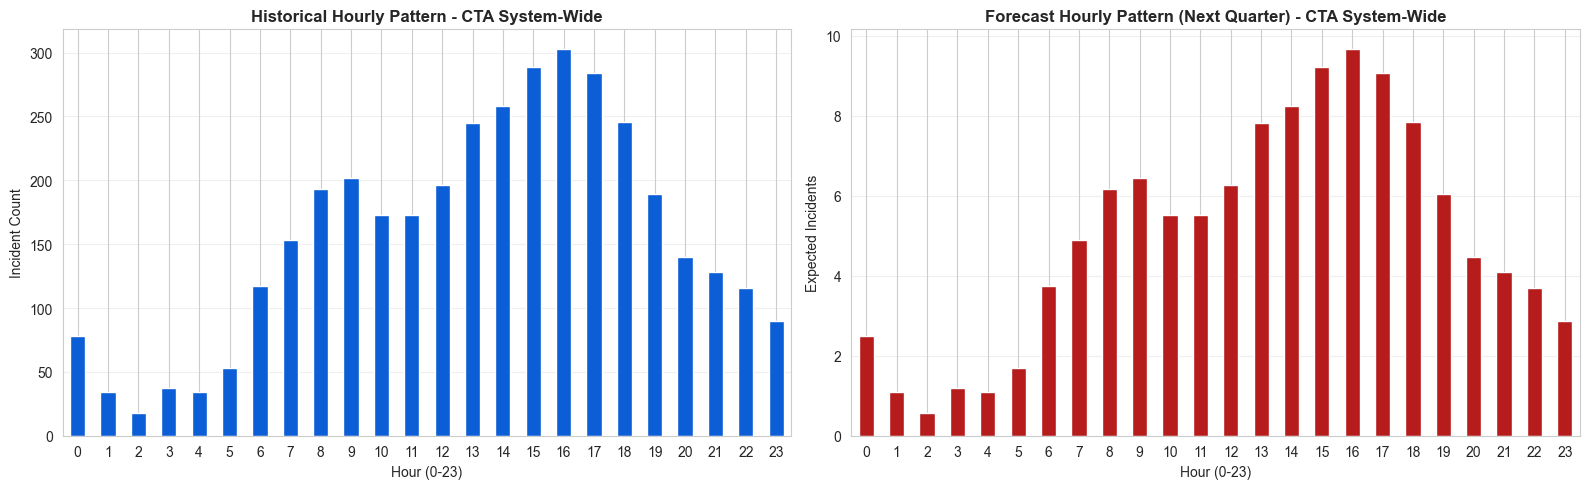


   ⚠️ HIGH-RISK HOURS (Next Quarter):
      4:00 PM: 9.7 incidents (8.1%)
      3:00 PM: 9.2 incidents (7.7%)
      5:00 PM: 9.1 incidents (7.6%)
      2:00 PM: 8.2 incidents (6.9%)
      6:00 PM: 7.9 incidents (6.6%)


In [10]:
print(f"\n{'='*80}")
print(f"🌐 SYSTEM-WIDE ANALYSIS (All CTA)")
print(f"{'='*80}")

df_system = df[df['parsed_date'].notna()]

print(f"   Total incidents: {len(df_system)}")
print(f"   Months: {df_system['year_month'].nunique()}")

plot_seasonal_decomposition(df_system, title="CTA System-Wide", save_path='test_results/system_seasonal.png')

result_system = train_sarimax(df_system, forecast_periods=6, title="CTA System-Wide")

if result_system:
    plot_forecast(result_system, save_path='test_results/system_forecast.png')
    next_quarter = result_system['forecast'][:3].sum()
    plot_hourly_risk(df_system[df_system['hour'].notna()], next_quarter, title="CTA System-Wide", save_path='test_results/system_hourly.png')

---
## 11. Summary Comparison Table

In [11]:
print(f"\n{'='*80}")
print("📊 SUMMARY COMPARISON - ALL LOCATIONS")
print(f"{'='*80}\n")

summary_data = []

for name, result, df_loc in [
    (LOC1_NAME, result_loc1, df_loc1),
    (LOC2_NAME, result_loc2, df_loc2),
    (LOC3_NAME, result_loc3, df_loc3),
    (LOC4_NAME, result_loc4, df_loc4),
    ("CTA System-Wide", result_system, df_system)
]:
    if result:
        hist_avg = result['historical'].mean()
        fcst_avg = result['forecast'].mean()
        change = ((fcst_avg - hist_avg) / hist_avg) * 100
        
        summary_data.append({
            "Location": name,
            "Incidents": len(df_loc),
            "Hist Avg/Mo": f"{hist_avg:.1f}",
            "Fcst Avg/Mo": f"{fcst_avg:.1f}",
            "Change": f"{change:+.1f}%",
            "MAE": f"{result['mae']:.2f}",
            "MAPE": f"{result['mape']:.1f}%"
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("\n" + "="*80)

# Save summary
summary_df.to_csv('test_results/location_summary.csv', index=False)
print("\n💾 Saved: test_results/location_summary.csv")


📊 SUMMARY COMPARISON - ALL LOCATIONS

       Location  Incidents Hist Avg/Mo Fcst Avg/Mo Change  MAE  MAPE
79th & Red Line         28         1.1         0.7 -36.4% 0.36  nan%
  95th/Dan Ryan         29         1.1         1.0  -6.9% 0.17  nan%
     Clark/Lake         29         1.1         0.8 -27.4% 0.22  nan%
CTA System-Wide       3749        27.6        39.2 +42.2% 3.14 11.6%


💾 Saved: test_results/location_summary.csv


---
## 12. Forecast Summary for Next 6 Months

In [12]:
print(f"\n{'='*80}")
print("📅 NEXT 6 MONTHS FORECAST - ALL LOCATIONS")
print(f"{'='*80}\n")

for name, result in [
    (LOC1_NAME, result_loc1),
    (LOC2_NAME, result_loc2),
    (LOC3_NAME, result_loc3),
    (LOC4_NAME, result_loc4)
]:
    if result:
        print(f"\n📍 {name}:")
        for i in range(min(6, len(result['forecast']))):
            date = result['forecast_dates'][i]
            value = result['forecast'][i]
            lower = result['forecast_lower'][i]
            upper = result['forecast_upper'][i]
            print(f"   {date.strftime('%b %Y')}: {value:.1f} incidents (range: {lower:.1f}-{upper:.1f})")


📅 NEXT 6 MONTHS FORECAST - ALL LOCATIONS


📍 79th & Red Line:
   May 2025: 0.7 incidents (range: 0.0-1.4)
   Jun 2025: 0.7 incidents (range: 0.0-1.4)
   Jul 2025: 0.7 incidents (range: 0.0-1.4)
   Aug 2025: 0.7 incidents (range: 0.1-1.4)
   Sep 2025: 0.7 incidents (range: 0.0-1.4)
   Oct 2025: 0.7 incidents (range: 0.0-1.4)

📍 95th/Dan Ryan:
   Apr 2025: 1.0 incidents (range: 1.0-1.0)
   May 2025: 1.0 incidents (range: 1.0-1.0)
   Jun 2025: 1.0 incidents (range: 1.0-1.0)
   Jul 2025: 1.0 incidents (range: 1.0-1.0)
   Aug 2025: 1.0 incidents (range: 1.0-1.0)
   Sep 2025: 1.0 incidents (range: 1.0-1.0)

📍 Clark/Lake:
   Feb 2025: 0.8 incidents (range: 0.2-1.4)
   Mar 2025: 0.8 incidents (range: 0.2-1.4)
   Apr 2025: 0.8 incidents (range: 0.2-1.4)
   May 2025: 0.8 incidents (range: 0.2-1.4)
   Jun 2025: 0.7 incidents (range: 0.2-1.3)
   Jul 2025: 0.8 incidents (range: 0.2-1.4)


---
## ✅ TEST COMPLETE!

### Files Generated:
```
test_results/
├── loc1_seasonal.png        (Seasonal decomposition)
├── loc1_forecast.png        (6-month forecast)
├── loc1_hourly.png          (Hourly risk pattern)
├── loc2_seasonal.png
├── loc2_forecast.png
├── loc2_hourly.png
├── loc3_seasonal.png
├── loc3_forecast.png
├── loc3_hourly.png
├── loc4_seasonal.png
├── loc4_forecast.png
├── loc4_hourly.png
├── system_seasonal.png
├── system_forecast.png
├── system_hourly.png
└── location_summary.csv     (Summary table)
```

### Summary:
- ✅ Best model (SARIMAX) tested on 4 locations + system-wide
- ✅ All plots generated and saved
- ✅ Performance metrics calculated
- ✅ 6-month forecasts with confidence intervals
- ✅ Hourly risk patterns analyzed

**Review the plots in the `test_results/` folder!**

---